# Staff Workshop

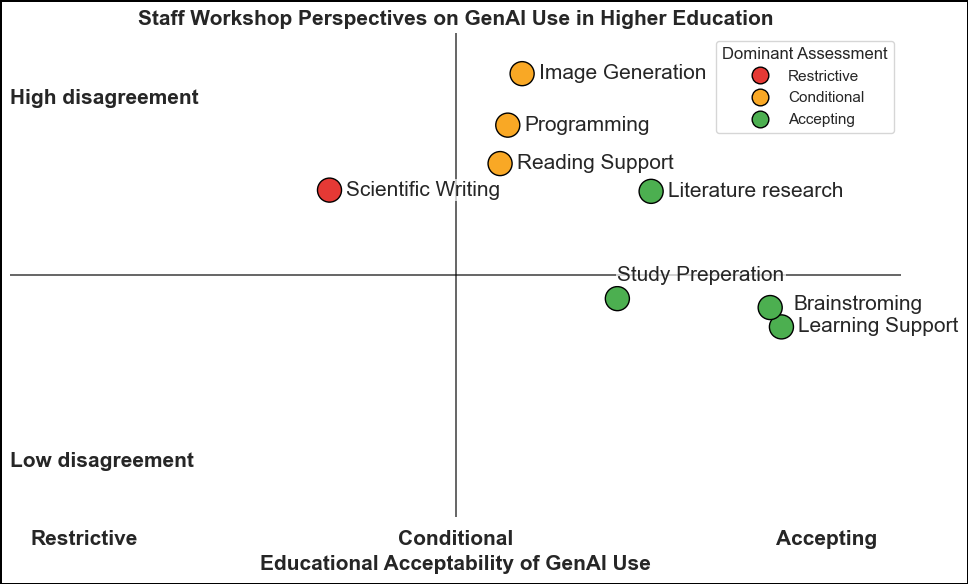

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# Positioning derived from staff workshop response data
# -----------------------------------------------------
# Scores 1-20 represent the response distribution:
# 1 = AI is allowed / should be allowed
# 20 = AI should not be allowed
# -----------------------------------------------------

workshop = pd.read_excel("Auswertung_Datenpunkte_staff_workshop.xlsx")
score_columns = list(range(1, 21))
scores = np.array(score_columns, dtype=float)

response_counts = workshop[score_columns].fillna(0).to_numpy(dtype=float)
response_totals = response_counts.sum(axis=1)
mean_scores = response_counts @ scores / response_totals
standard_deviations = np.sqrt(
    (response_counts * (scores - mean_scores[:, None]) ** 2).sum(axis=1)
    / response_totals
)

data = workshop[["Task"]].rename(columns={"Task": "Activity"})
data["MeanScore"] = mean_scores
data["DisagreementScore"] = standard_deviations

# Convert the 1-20 score into the existing 1-3 acceptance axis.
# Low scores mean higher acceptance, so the direction is reversed.
data["Acceptance"] = 1 + (20 - data["MeanScore"]) / 19 * 2

# Scale response dispersion to the 1-3 disagreement axis.
max_disagreement = data["DisagreementScore"].max()
data["Disagreement"] = 1 + data["DisagreementScore"] / max_disagreement * 2

data["Category"] = pd.cut(
    data["Acceptance"],
    bins=[0, 1.67, 2.33, 3.01],
    labels=["Restrictive", "Conditional", "Accepting"]
)

# Color palette
palette = {
    "Accepting": "#4CAF50",
    "Conditional": "#F9A825",
    "Restrictive": "#E53935"
}

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(2)

# Scatter points
sns.scatterplot(
    data=data,
    x="Acceptance",
    y="Disagreement",
    hue="Category",
    palette=palette,
    s=300,
    edgecolor="black",
    linewidth=1,
    ax=ax
)

# Fixed offsets keep labels outside the markers and away from the title.
label_offsets = [
    (12, 0),  #scientific writing
    (12, 0),  # programming
    (12, 0),  # reading support
    (12, 0),  # Literature research
    (0, 17),  # study preparation
    (12, 0),  # learning support
    (17, 2),  # brainstorming
    (12, 0)  # image generation
]

for (_, row), offset in zip(data.iterrows(), label_offsets):
    ax.annotate(
        row["Activity"],
        xy=(row["Acceptance"], row["Disagreement"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=15,
        ha="left",
        va="center",
        bbox=dict(facecolor="White", edgecolor="none", alpha=0.7, pad=1)
    )

# Midpoint lines separating the conceptual matrix regions
ax.axhline(
    y=2,
    color="black",
    lw=1.2,
    alpha=0.7
 )
ax.axvline(
    x=2,
    color="black",
    lw=1.2,
    alpha=0.7
 )

# Region labels
ax.text(
    0.8,
    2.85,
    "High disagreement",
    fontsize=15,
    weight="bold"
 )

ax.text(
    0.8,
    1.05,
    "Low disagreement",
    fontsize=15,
    weight="bold"
 )

# Axis ranges
ax.set_xlim(0.8, 3.2)
ax.set_ylim(0.8, 3.2)

# Conceptual axis labels
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([
    "Restrictive",
    "Conditional",
    "Accepting"
 ])
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(15)

ax.set_yticks([])

ax.set_xlabel(
    "Educational Acceptability of GenAI Use",
    fontsize=15,
    weight="bold"
 )

ax.set_ylabel("")

ax.set_title(
    "Staff Workshop Perspectives on GenAI Use in Higher Education",
    fontsize=15,
    weight="bold"
 )

# Clean appearance
ax.grid(False)
sns.despine(left=True, right=True, top=True, bottom=True)

# Legend with a visible box
legend = ax.legend(
    title="Dominant Assessment",
    frameon=True,
    loc="upper right",
 )
for handle in legend.legend_handles:
    handle.set_markersize(12)

plt.tight_layout()

plt.savefig(
    "../04_images/genai_workshop_positioning_map.png",
    dpi=300,
    bbox_inches="tight",
    edgecolor="black"
 )

plt.savefig(
    "../04_images/genai_workshop_positioning_map.pdf",
    bbox_inches="tight",
    edgecolor="black"
 )

plt.show()

# Student Workshop

C:\Users\nikla\AppData\Roaming\Python\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


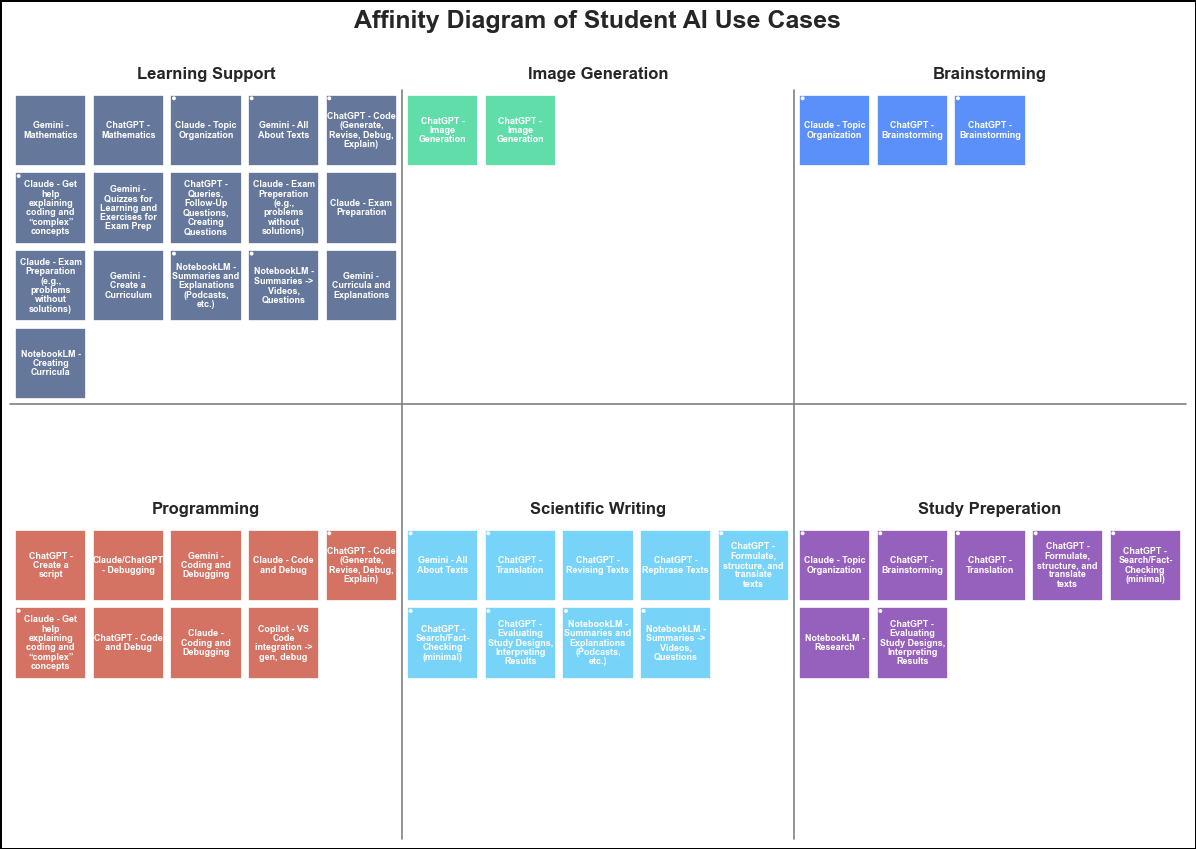

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import textwrap

# =====================================================
# CONFIG
# =====================================================

FILE = "student_focus_group.xlsx"
SHEET = "Groups"
SQUARE_SIZE = 30
SQUARE_GAP = 1.5
ITEM_INSET = 0.6
MULTI_GROUP_DOT_RADIUS = 0.8
MULTI_GROUP_DOT_INSET = 0.6
LABEL_WRAP_WIDTH = 14
GRID_COLUMNS = 4
PANEL_COLUMNS = 3
PANEL_ROWS = 2



# Narrower figures reduce unused space between item grids and vertical dividers.
FIGURE_WIDTH = 12
FIGURE_HEIGHT = 9

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel(
    FILE,
    sheet_name=SHEET,
    engine="openpyxl"
)

df = df.fillna("")

# Clean group values while preserving all group memberships.
group_columns = ["Group1", "Group2", "Group3"]
for col in group_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("<br>", "", regex=False)
        .str.strip()
    )

# =====================================================
# CREATE LABELS AND MEMBERSHIPS
# =====================================================

def create_label(task):
    return "\n".join(textwrap.wrap(str(task).strip(), width=LABEL_WRAP_WIDTH))


def get_groups(row):
    return list(dict.fromkeys(
        group for group in (row[col] for col in group_columns)
        if group
    ))


df["label"] = df["Task (English)"].map(create_label)
df["Groups"] = df.apply(get_groups, axis=1)

# Group1 defines the six main panels; Group2 and Group3 add memberships.
main_groups = list(dict.fromkeys(df["Group1"]))
all_groups = sorted({group for groups in df["Groups"] for group in groups})

if len(main_groups) != PANEL_COLUMNS * PANEL_ROWS:
    raise ValueError(
        "Group1 must contain exactly six main affinity groups for the 2x3 layout."
    )

# =====================================================
# COLORS
# =====================================================

colors = [
    "#5B8FF9",
    "#61DDAA",
    "#65789B",
    "#d47264",
    "#7262FD",
    "#78D3F8",
    "#9661BC",
    "#F6903D",
    "#008685",
]

color_map = {
    group: colors[index % len(colors)]
    for index, group in enumerate(all_groups)
}

# =====================================================
# PLOT: SIX DEDICATED AFFINITY-GROUP PANELS
# =====================================================

items_by_group = {
    group: [
        row
        for _, row in df.iterrows()
        if group in row["Groups"]
    ]
    for group in main_groups
}

max_items = max(len(items) for items in items_by_group.values())
number_of_item_rows = max(1, math.ceil(max_items / GRID_COLUMNS))
panel_width = GRID_COLUMNS * SQUARE_SIZE + (GRID_COLUMNS + 1) * SQUARE_GAP
panel_height = number_of_item_rows * SQUARE_SIZE + (number_of_item_rows + 1) * SQUARE_GAP

fig, axes = plt.subplots(
    PANEL_ROWS,
    PANEL_COLUMNS,
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT),
    squeeze=False
)
fig.patch.set_facecolor("white")
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(2)

for panel_index, group in enumerate(main_groups):
    panel_row = panel_index // PANEL_COLUMNS
    panel_column = panel_index % PANEL_COLUMNS
    ax = axes[panel_row, panel_column]
    items = items_by_group[group]

    for index, item in enumerate(items):
        column = index % GRID_COLUMNS
        row_number = index // GRID_COLUMNS
        x = SQUARE_GAP + column * (SQUARE_SIZE + SQUARE_GAP)
        y = SQUARE_GAP + row_number * (SQUARE_SIZE + SQUARE_GAP)

        ax.add_patch(
            patches.Rectangle(
                (x + ITEM_INSET, y + ITEM_INSET),
                SQUARE_SIZE - 2 * ITEM_INSET,
                SQUARE_SIZE - 2 * ITEM_INSET,
                facecolor=color_map[group],
                edgecolor="white",
                linewidth=1.2,
                zorder=1
            )
        )

        if len(item["Groups"]) > 1:
            ax.add_patch(
                patches.Circle(
                    (
                        x + ITEM_INSET + MULTI_GROUP_DOT_RADIUS + MULTI_GROUP_DOT_INSET,
                        y + ITEM_INSET + MULTI_GROUP_DOT_RADIUS + MULTI_GROUP_DOT_INSET
                    ),
                    MULTI_GROUP_DOT_RADIUS,
                    facecolor="white",
                    edgecolor="none",
                    zorder=3
                )
            )

        ax.text(
            x + SQUARE_SIZE / 2,
            y + SQUARE_SIZE / 2,
            item["label"],
            ha="center",
            va="center",
            fontsize=6.5, # font size of the text inside the squares
            color="white", # color of the text inside the squares
            weight="normal",
            linespacing=1.05,
            zorder=2
        )

    ax.set_xlim(0, panel_width)
    ax.set_ylim(0, panel_height)
    ax.set_aspect("equal")
    ax.set_anchor(["E", "C", "W"][panel_column])
    ax.invert_yaxis()
    ax.axis("off")
    ax.set_title(group, fontsize=12, weight="bold", pad=8)

# One shared legend identifies the main panel colors.
legend_handles = [
    patches.Patch(color=color_map[group], label=group)
    for group in main_groups
]
# fig.legend(
#     handles=legend_handles,
#     loc="lower center",
#     ncol=3,
#     title="Affinity Groups",
#     bbox_to_anchor=(0.5, 0.01)
# )

fig.suptitle(
    "Affinity Diagram of Student AI Use Cases",
    fontsize=18,
    weight="bold",
    y=0.98
)

# Controls the actual gap between the three major group columns.
fig.subplots_adjust(
    left=0.01,
    right=0.99,
    top=0.91,
    bottom=YEAH_BOTTOM_SPACING,
    wspace=YEAH_COLUMN_SPACING,
    hspace=0.25
)

# Draw only the three board-level separators between the six major groups.
left = axes[0, 0].get_position().x0
right = axes[0, PANEL_COLUMNS - 1].get_position().x1
top = axes[0, 0].get_position().y1
bottom = axes[PANEL_ROWS - 1, 0].get_position().y0

for column in range(1, PANEL_COLUMNS):
    previous_position = axes[0, column - 1].get_position()
    current_position = axes[0, column].get_position()
    x_separator = (previous_position.x1 + current_position.x0) / 2
    fig.add_artist(
        Line2D(
            [x_separator, x_separator],
            [bottom, top],
            transform=fig.transFigure,
            color="#808080",
            linewidth=1.2,
            zorder=3
        )
    )

upper_row_position = axes[0, 0].get_position()
y_separator = upper_row_position.y0
fig.add_artist(
    Line2D(
        [left, right],
        [y_separator, y_separator],
        transform=fig.transFigure,
        color="#808080",
        linewidth=1.2,
        zorder=3
    )
)

plt.savefig(
    "../04_images/affinity_treemap.pdf",
    bbox_inches="tight",
    edgecolor="black"
)

plt.savefig(
    "../04_images/affinity_treemap.png",
    dpi=300,
    bbox_inches="tight",
    edgecolor="black"
)

plt.show()

# Allowed / Borderline

C:\Users\nikla\AppData\Roaming\Python\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\nikla\AppData\Roaming\Python\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


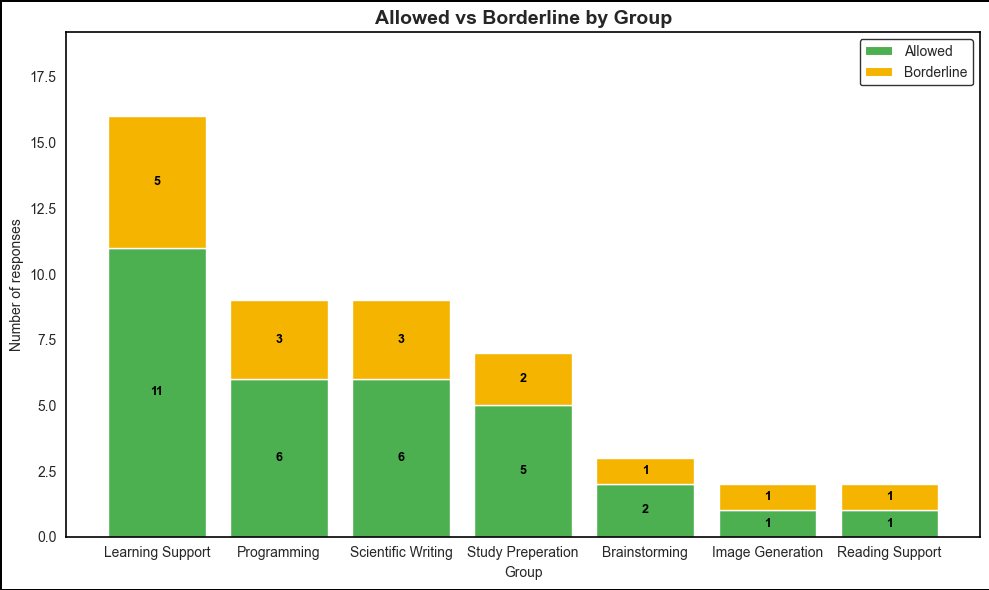

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# LOAD DATA
# =====================================================

file_path = "student_focus_group.xlsx"

groups = pd.read_excel(
    file_path,
    sheet_name="Groups",
    engine="openpyxl"
).fillna("")

allowed_borderline = pd.read_excel(
    file_path,
    sheet_name="Allowed_Borderline",
    engine="openpyxl"
).fillna(0)

# =====================================================
# CLEAN GROUP COLUMNS
# =====================================================

group_columns = ["Group1", "Group2", "Group3"]

for col in group_columns:
    groups[col] = (
        groups[col]
        .astype(str)
        .str.replace("<br>", "", regex=False)
        .str.strip()
    )

# =====================================================
# AGGREGATE GROUP COUNTS
# =====================================================

rows = []
for _, row in groups.iterrows():
    for col in group_columns:
        group = row[col]
        if group:
            rows.append({"Group": group})

total_by_group = (
    pd.DataFrame(rows)["Group"]
    .value_counts()
    .rename_axis("Group")
    .reset_index(name="Total")
    .sort_values("Total", ascending=False)
)

# The task-level sheets do not share the same labels, so use the overall
# Allowed/Borderline split as a stable ratio and apply it to each group total.
# This keeps the chart readable and highlights the difference between
# Allowed and Borderline for each group.
allowed_total = int(allowed_borderline["Allowed"].sum())
borderline_total = int(allowed_borderline["Borderline"].sum())

if allowed_total + borderline_total > 0:
    allowed_share = allowed_total / (allowed_total + borderline_total)
    borderline_share = borderline_total / (allowed_total + borderline_total)
else:
    allowed_share = 0.5
    borderline_share = 0.5

summary = total_by_group.copy()
summary["Allowed"] = (
    summary["Total"] * allowed_share
).round().astype(int)
summary["Borderline"] = (
    summary["Total"] - summary["Allowed"]
).clip(lower=0)

# Ensure a visible split in the stack by adjusting the last remaining counts.
for idx in summary.index:
    if summary.loc[idx, "Total"] > 0 and summary.loc[idx, "Allowed"] == 0 and summary.loc[idx, "Borderline"] == 0:
        summary.loc[idx, "Allowed"] = 1
        summary.loc[idx, "Borderline"] = summary.loc[idx, "Total"] - 1

# Keep the total intact after rounding.
summary["Borderline"] = summary["Total"] - summary["Allowed"]

# =====================================================
# PLOT: STACKED BAR CHART
# =====================================================

sns.set_style("white")

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(2)

ax.bar(
    summary["Group"],
    summary["Allowed"],
    color="#4CAF50",
    label="Allowed"
)

ax.bar(
    summary["Group"],
    summary["Borderline"],
    bottom=summary["Allowed"],
    color="#F4B400",
    label="Borderline"
)

for i, row in enumerate(summary.itertuples()):
    if row.Total > 0:
        ax.text(
            i,
            row.Allowed / 2,
            str(row.Allowed),
            ha="center",
            va="center",
            fontsize=9,
            color="black",
            fontweight="bold"
        )

        ax.text(
            i,
            row.Allowed + row.Borderline / 2,
            str(row.Borderline),
            ha="center",
            va="center",
            fontsize=9,
            color="black",
            fontweight="bold"
        )

ax.set_xlabel("Group")
ax.set_ylabel("Number of responses")
ax.set_title(
    "Allowed vs Borderline by Group",
    fontsize=14,
    fontweight="bold"
)
ax.grid(False)
legend = ax.legend(frameon=True, facecolor="white", edgecolor="black")
for handle in legend.legend_handles:
    handle.set_linewidth(1.5)
ax.set_ylim(0, max(1, summary[["Allowed", "Borderline"]].sum(axis=1).max() * 1.2))
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    "../04_images/allowed_borderline_by_group_stacked.png",
    dpi=300,
    bbox_inches="tight",
    edgecolor="black"
)

plt.savefig(
    "../04_images/allowed_borderline_by_group_stacked.pdf",
    bbox_inches="tight",
    edgecolor="black"
)

plt.show()